# Synthetic (SMT) sweep analysis

Analyses the synthetic sweep (`cluster/`): a multi-head MLP trained on datasets of
increasing difficulty, with and without the learned-abstention head. The focus is the
abstention story -- why harder datasets are harder, and how much abstaining buys back.

Paper-ready figures are written to `figs/fig_*.{png,pdf}` as they render:

| figure | what it shows |
|---|---|
| `fig_feature_separability_<dataset>` | per-feature class-conditional densities + overlap, baseline vs hardest |
| `fig_risk_coverage` | risk vs coverage: abstention's coverage/accuracy trade-off across `o` |
| `fig_selective_vs_o` | selective accuracy (kept rows) vs `o` on `balanced_hard` |
| `fig_cascade_vs_abstention_selective` | non-abstention vs abstention accuracy comparison, per dataset |
| `fig_selective_risk` | selective-risk curves (`baseline` + `harder`): abstention vs no-rejection |

Prereq: run the sweep first (`bash cluster/submit.sh` on SLURM, or
`bash cluster/run_local.sh` locally), then run this notebook from the repo root.


## Load every run

Loads the manifest + each run's metrics into one dataframe, with helpers to slice by study and average over seeds.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd

# find the repo root by walking up until cluster/manifest.json appears
root = Path.cwd()
while not (root / "cluster" / "manifest.json").exists() and root != root.parent:
    root = root.parent
manifest = json.loads((root / "cluster" / "manifest.json").read_text())
print("runs in matrix:", len(manifest["runs"]))


def load_rows():
    """One flat row per run that produced a metrics file. Hyperparameters + study
    tags come from the manifest; scores from the run's metrics JSON."""
    rows, missing = [], []
    for r in manifest["runs"]:
        p = root / r["metrics"]
        if not p.exists():
            missing.append(r["run_id"]); continue
        m = json.loads(p.read_text())
        d, mech = m["defect_head"], m["mechanism_accuracy"]
        row = {
            "run_id": r["run_id"], "dataset": r["dataset"], "loss": r["loss"],
            "o": r["o"], "seed": r["seed"], "hidden": r.get("hidden"),
            "dropout": r.get("dropout"), "class_weight": r.get("class_weight"),
            "lr": r.get("lr"), "epochs": r.get("epochs"),
            "studies": r.get("studies", []),
            "defect_acc": d["accuracy"], "defect_wf1": d["weighted_f1"],
            "defect_macrof1": d["macro_f1"],
            "bayes": m["bayes_optimal_accuracy"],
            "gap_to_bayes": m["bayes_optimal_accuracy"] - d["accuracy"],
            "mech_joint": mech["joint_accuracy"],
            "risk_mae": m["risk_mae"],
        }
        ab = m.get("abstention")
        if ab:
            row["mean_abstain"] = ab["mean_abstain_prob"]
            half = ab["by_threshold"].get("0.5", {})
            row["coverage@0.5"] = half.get("coverage")
            row["selective_acc@0.5"] = half.get("selective_accuracy")
        rows.append(row)
    if missing:
        print(f"WARNING: {len(missing)} runs have no metrics yet (still training?):")
        print("  " + ", ".join(missing[:12]) + (" ..." if len(missing) > 12 else ""))
    return pd.DataFrame(rows)


df = load_rows()
print(f"loaded {len(df)} of {len(manifest['runs'])} runs")


def study(name):
    """Rows tagged with a study (core, payoff, capacity, dropout, lr, class_weight)."""
    if not len(df) or "studies" not in df.columns:
        return df.iloc[0:0]
    return df[df["studies"].apply(lambda s: name in (s or []))]


def seed_mean(frame, keys, metrics):
    """Average over seeds -> one row per config (keeps NaN-keyed groups, e.g. o=None)."""
    metrics = [m for m in metrics if m in frame.columns]
    return frame.groupby(keys, dropna=False)[metrics].mean().reset_index()


def core_grid():
    """(core rows, dataset order, losses, bar x-positions, bar width)."""
    core = study("core")
    datasets = list(manifest["datasets"])
    losses = [l for l in ["cascade", "abstention"] if l in set(core["loss"])] if len(core) else []
    x = np.arange(len(datasets)); w = 0.8 / max(len(losses), 1)
    return core, datasets, losses, x, w

runs in matrix: 1332
loaded 1332 of 1332 runs


## Plot style

Shared paper style + a `save_fig` helper that writes `figs/fig_*.{png,pdf}`.

In [2]:
# Shared paper-quality plotting style + a figs/ saver. Consistent colors for the two
# losses everywhere; horizontal layouts + zoomed axes so small differences are legible.
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.size": 15, "axes.titlesize": 15, "axes.titleweight": "bold",
    "axes.labelsize": 12, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"cascade": "#2c7fb8", "abstention": "#e6550d", "bayes": "#333333"}

# Per-dataset colors: the SAME color identifies a dataset in every figure (risk-coverage
# frontier, selective-risk panels, ...). Canonical map (baseline=blue, harder=orange,
# imbalanced=green); any dataset not listed falls back to the tab10 cycle by position.
_TAB10 = plt.get_cmap("tab10")
DSCOLORS = {d: _TAB10(i) for i, d in enumerate(
    ["baseline", "harder", "imbalanced", "balanced", "balanced_hard", "hard"])}


def dscolor(d, i=0):
    """Consistent color for a dataset (falls back to tab10 by position i)."""
    return DSCOLORS.get(d, _TAB10(i % 10))


FIGDIR = root / "tex/img"
FIGDIR.mkdir(exist_ok=True)


def save_fig(fig, name):
    """Write a paper copy (PNG + PDF) to figs/ and print the path."""
    for ext in ("png", "pdf"):
        fig.savefig(FIGDIR / f"{name}.{ext}")
    print(f"saved {FIGDIR}/{name}.png (+ .pdf)")

## Why the hardest problem is harder (feature separability)

Per-feature class-conditional densities for the **baseline** vs the **hardest** dataset -- visually compare the increased overlap. Low open/bridge overlap = the feature separates the defects; high overlap = it carries little signal, which is what makes the task hard. **Saved: `fig_feature_separability_<dataset>`.**

saved /fs1/projects/ProtoOKN/medical-device-rca/tex/img/fig_feature_separability_baseline.png (+ .pdf)


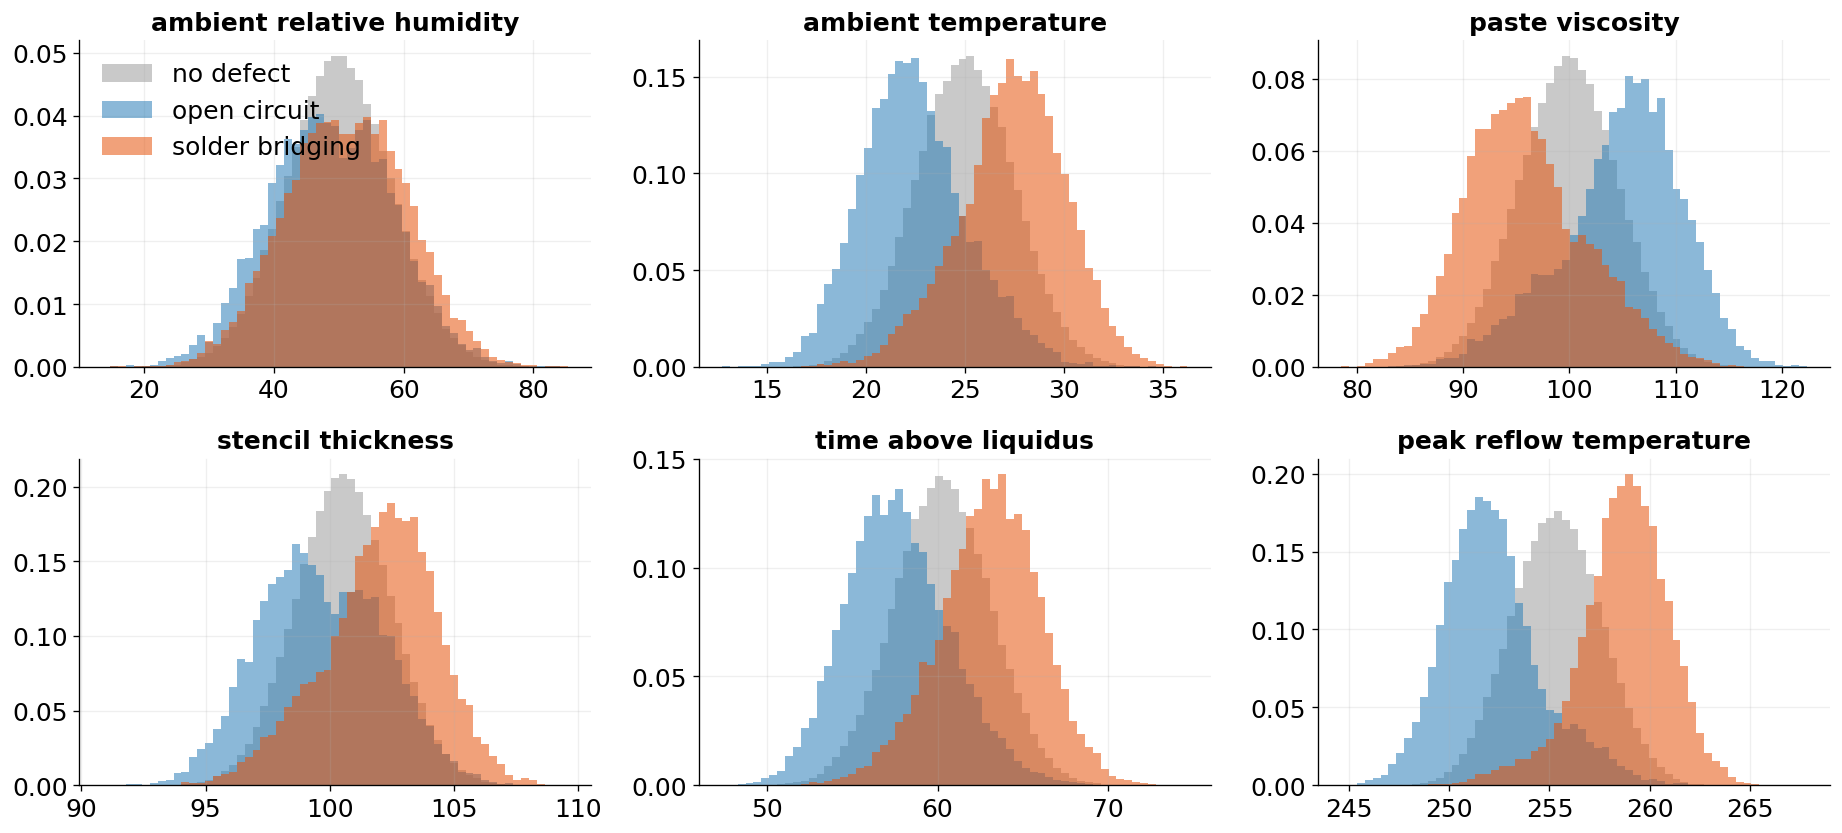

saved /fs1/projects/ProtoOKN/medical-device-rca/tex/img/fig_feature_separability_harder.png (+ .pdf)


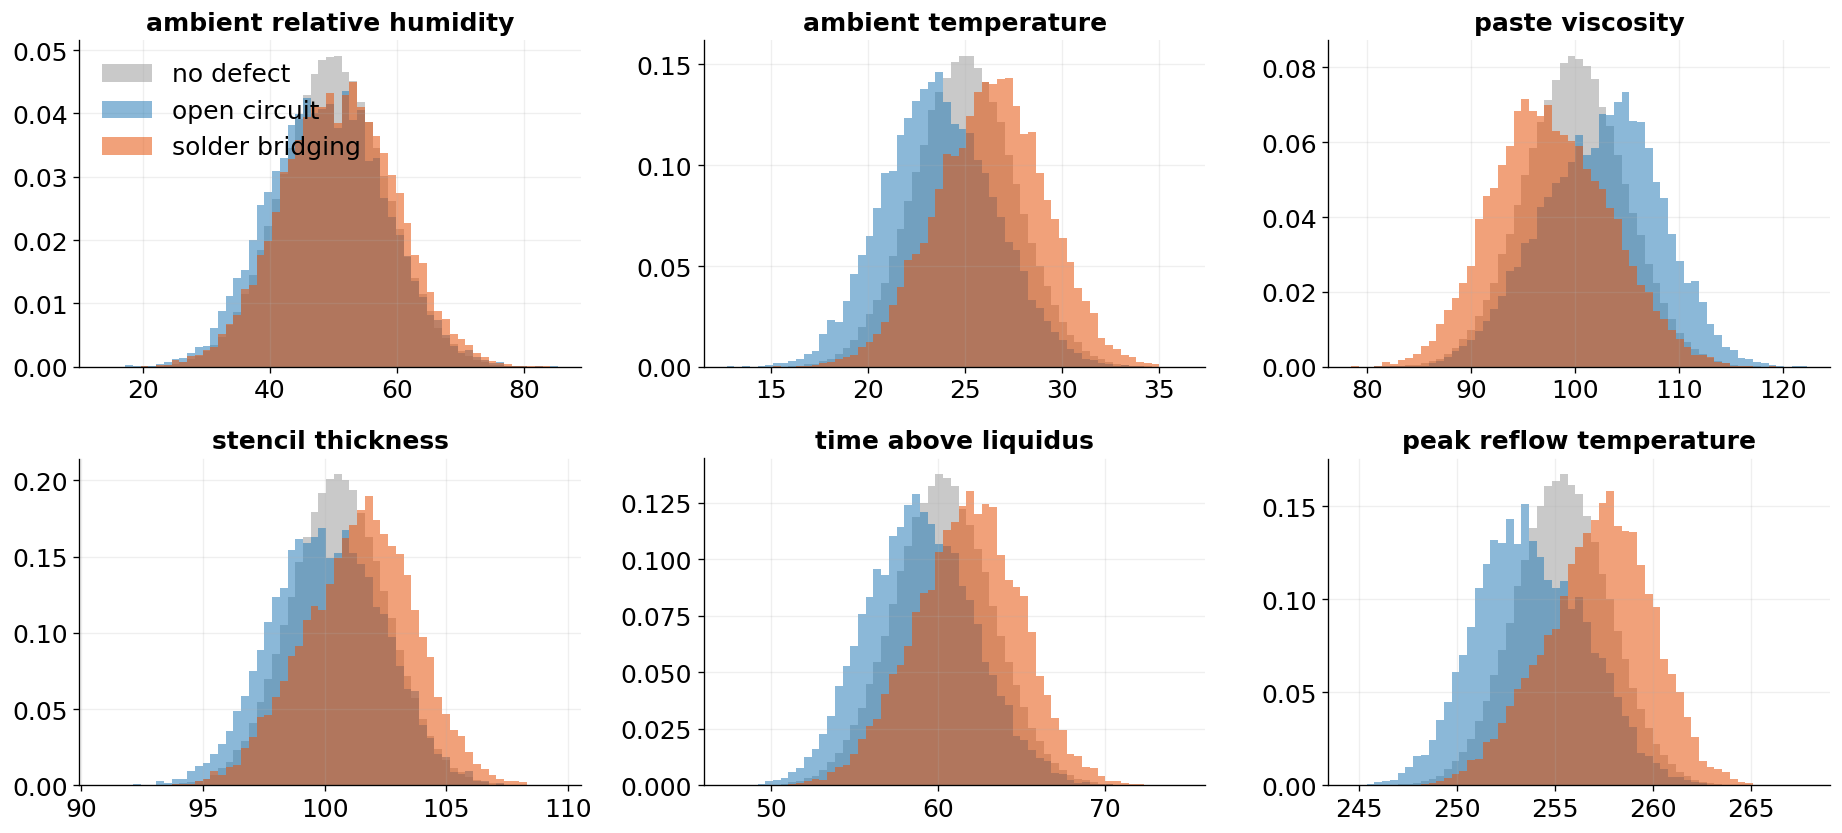

In [3]:
# FEATURE SEPARABILITY: per-feature class-conditional densities, drawn for the BASELINE
# (well-separated) and the HARDEST dataset (more overlap) so you can VISUALLY compare the
# increased overlap. LOW open/bridge overlap => the feature separates the defects; HIGH
# overlap => it carries little signal, which is what makes the task hard. Dashed lines are
# the spec limits (lsl / usl). Reads only the dataset CSVs + the spec YAML.
csvs = {d: root / "data" / "cluster" / f"{d}.csv" for d in manifest["datasets"]}
csvs = {d: p for d, p in csvs.items() if p.exists()}
if csvs:
    def _berr(p):
        dd = pd.read_csv(p, usecols=lambda c: c.startswith("p_"))
        return float((1 - dd.to_numpy().max(1)).mean())

    # spec limits (lsl/usl) + the monitored feature ids from the YAML (no pyyaml dep)
    lims, cur, in_p = {}, None, False
    for line in (root / "domain" / "smt_paper.yaml").read_text().splitlines():
        if not line.strip() or line.lstrip().startswith("#"):
            continue
        if not line[0].isspace():
            in_p = line.strip().startswith("parameters:"); cur = None; continue
        if not in_p:
            continue
        s = line.strip()
        if s.startswith("- id:"):
            cur = s.split("id:", 1)[1].split("#")[0].strip(); lims[cur] = []
        elif cur and (s.startswith("lsl:") or s.startswith("usl:")):
            lims[cur].append(float(s.split(":", 1)[1].split("#")[0]))
    CLS = [("no_defect", "no defect", "#9e9e9e"),
           ("open_circuit", "open circuit", COLORS["cascade"]),
           ("solder_bridging", "solder bridging", COLORS["abstention"])]

    def featsep(ds):
        dh = pd.read_csv(csvs[ds])
        feats = [f for f in lims if f in dh.columns]     # exactly the process features, spec order
        ncol = 3; nrow = int(np.ceil(len(feats) / ncol))
        fig, axes = plt.subplots(nrow, ncol, figsize=(5.2 * ncol, 3.6 * nrow), squeeze=False)
        for k, f in enumerate(feats):
            ax = axes[k // ncol][k % ncol]
            bins = np.linspace(dh[f].min(), dh[f].max(), 60)
            hists = {}
            for key, lab, col in CLS:
                v = dh.loc[dh["defect_label"] == key, f].to_numpy()
                if len(v):
                    ax.hist(v, bins=bins, density=True, alpha=0.55, color=col, label=lab)
                    h, _ = np.histogram(v, bins=bins); hists[key] = h / max(h.sum(), 1)
            if "open_circuit" in hists and "solder_bridging" in hists:
                ov = float(np.minimum(hists["open_circuit"], hists["solder_bridging"]).sum())
            else:
                ov = float("nan")
            # for lim in lims.get(f, []):
                # ax.axvline(lim, ls="--", color="k", lw=1, alpha=0.7)
            ax.set_title(f"{f}".replace("_", " "), fontsize=15); ax.grid(alpha=0.2)
        for k in range(len(feats), nrow * ncol):
            axes[k // ncol][k % ncol].axis("off")
        axes[0][0].legend(fontsize=15)
        # fig.suptitle(f"Feature values by defect class (density) -- {ds} (Bayes err {_berr(csvs[ds]):.3f})"
        #              "  --  low overlap = the class colors separate", fontweight="bold")
        fig.tight_layout(); save_fig(fig, f"fig_feature_separability_{ds}"); plt.show()

    hardest = max(csvs, key=lambda d: _berr(csvs[d]))
    baseline = "baseline" if "baseline" in csvs else min(csvs, key=lambda d: _berr(csvs[d]))
    for ds in dict.fromkeys([baseline, hardest]):        # baseline first, dedup if same
        featsep(ds)
else:
    print("no dataset CSVs found (need data/cluster/*.csv on the cluster)")

## Risk vs coverage

The selective-classification figure: coverage vs selective accuracy as the payoff `o` sweeps (one operating point per model); star = non-abstention at full coverage. **Saved: `fig_risk_coverage`.**

saved /fs1/projects/ProtoOKN/medical-device-rca/tex/img/fig_risk_coverage.png (+ .pdf)


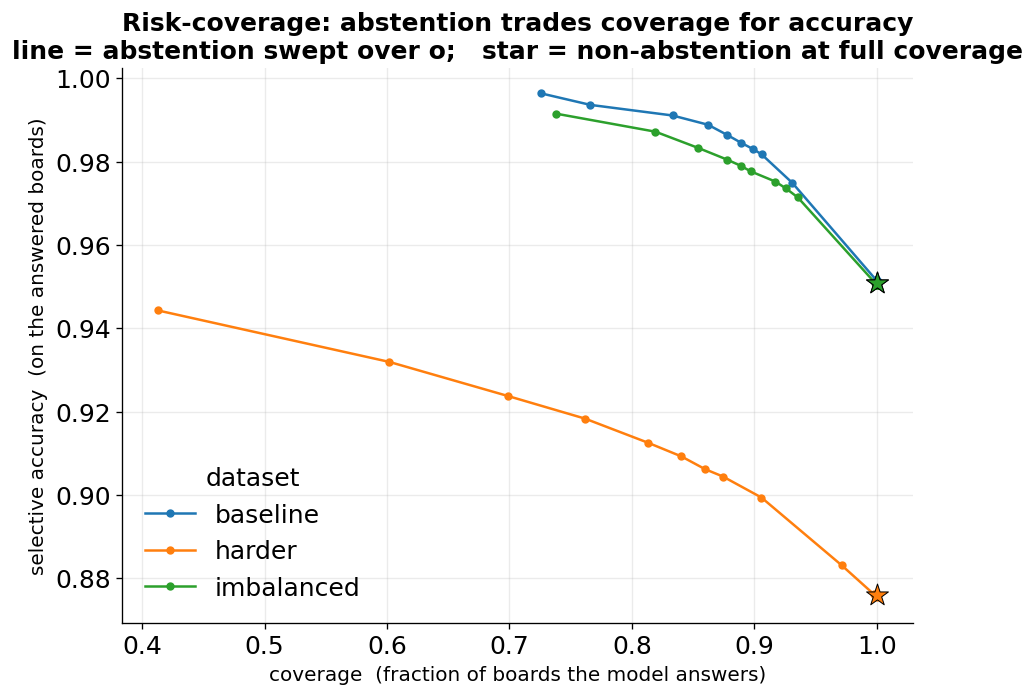

In [4]:
# PAPER FIGURE: risk-coverage curve. Each abstention model (one per payoff o) gives
# one (coverage, selective-accuracy) point at the h=0.5 accept threshold; sweeping
# o = 1 -> 4 traces the frontier. The star marks the non-abstention model at full coverage (it never
# abstains). Points up-and-left of a star => abstaining buys accuracy on the boards
# the model chooses to answer.
RC_DATASETS = ["baseline", "harder", "imbalanced"]    # baseline + harder + imbalanced
pay = study("payoff"); core = study("core")
if len(pay):
    sm = seed_mean(pay, ["dataset", "o"], ["coverage@0.5", "selective_acc@0.5"])
    fig, ax = plt.subplots(figsize=(8.5, 6))
    for j, d in enumerate([d for d in RC_DATASETS if d in set(pay["dataset"])]):
        c = dscolor(d, j)
        s = sm[sm.dataset == d].sort_values("coverage@0.5")
        ax.plot(s["coverage@0.5"], s["selective_acc@0.5"], "-o", ms=4,
                color=c, label=d)
        cba = core[(core.dataset == d) & (core.loss == "cascade")]["defect_acc"].mean()
        ax.scatter(1.0, cba, marker="*", s=190, color=c,
                   edgecolor="k", linewidth=0.6, zorder=5)
    ax.set_xlabel("coverage  (fraction of boards the model answers)")
    ax.set_ylabel("selective accuracy  (on the answered boards)")
    ax.set_title("Risk-coverage: abstention trades coverage for accuracy\n"
                 "line = abstention swept over o;   star = non-abstention at full coverage")
    ax.legend(title="dataset", loc="lower left")
    save_fig(fig, "fig_risk_coverage"); plt.show()
else:
    print("no payoff-study runs with metrics yet")

## Selective-classification analysis (threshold-swept)

Loads the saved checkpoints and sweeps the **rejection threshold** on each model (the standard selective-risk view). Runs on the cluster (needs `results/cluster/*.pt` + `data/cluster/*.csv`); builds `sel_table` + the `_find/_infer/_risk_cov` helpers used below.

In [5]:
# Selective-classification analysis (replicates the toy_example). Unlike the cells
# above (which read only the JSON metrics), this loads the SAVED abstention checkpoints and
# sweeps coverage on ONE model -- the learned reject head vs the same model's softmax
# confidence, both referenced to that model's own full-coverage (CE) error.
# Needs results/cluster/*.pt + data/cluster/*.csv, so run it on the cluster (or after
# rsync-ing them back). Edit SEL_O / SEL_SEED / SEL_COVERAGE to probe other settings.
import sys
sys.path.insert(0, str(root))            # so `import mlp` works regardless of cwd
import torch
import mlp

SEL_O, SEL_SEED, SEL_COVERAGE = 2.0, 0, 0.80
_spec = mlp.load_spec(str(root / "domain" / "smt_paper.yaml"))
_names = mlp.defect_names(_spec)
_ids = mlp.param_ids(_spec)
_covs = np.linspace(0.05, 1.0, 40)


def _find(dataset, loss, o, seed):
    for r in manifest["runs"]:
        if (r["dataset"] == dataset and r["loss"] == loss and r["seed"] == seed
                and (r["o"] == o if loss == "abstention" else True)):
            return r
    return None


def _infer(run, dfd):
    """Test-split predictions for one checkpoint (standardized with its stored stats)."""
    model, ckpt = mlp.load_model(str(root / run["model"]), device="cpu")
    te = np.where(dfd["split"].to_numpy() == "test")[0]
    mu, sd = ckpt["standardize"]["mu"], ckpt["standardize"]["sd"]
    X = ((dfd.iloc[te][_ids].to_numpy(np.float32) - mu) / sd).astype(np.float32)
    y = dfd.iloc[te]["defect_label"].map({n: i for i, n in enumerate(_names)}).to_numpy()
    p = model.predict(torch.from_numpy(X))
    d = {"y": y, "argmax": p["defect_argmax"].cpu().numpy(),
         "real": p["defect_prob"].cpu().numpy(), "te": te,
         "abstain": bool(getattr(model, "abstain", False))}
    if d["abstain"]:
        d["r"] = p["abstain_prob"].cpu().numpy()
    return d


def _risk_cov(score, correct, covs=_covs):
    """Rank-based selective risk: accept the most-confident `cov` fraction (highest
    score first) -> accepted error at each coverage."""
    order = np.argsort(-score); n = len(score)
    return np.array([1 - correct[order[:max(1, int(round(c * n)))]].mean() for c in covs])


def _bayes_err(dfd, te):
    post = dfd.iloc[te][[f"p_{n}" for n in _names]].to_numpy()
    return float((1 - post.max(1)).mean())


SEL_SEEDS = sorted({r["seed"] for r in manifest["runs"]})   # every seed -> mean curve + seed band

sel, _rows = {}, []
for ds in manifest["datasets"]:
    csv = root / "data" / "cluster" / f"{ds}.csv"
    if not csv.exists():
        continue
    dfd = None
    abst_stack, conf_stack, ce_list = [], [], []      # one curve/value per seed
    bayes, ia_last = None, None
    for seed in SEL_SEEDS:
        abst = _find(ds, "abstention", SEL_O, seed)   # ONE model for all three curves
        if not (abst and (root / abst["model"]).exists()):
            continue
        if dfd is None:
            dfd = pd.read_csv(csv)
        ia = _infer(abst, dfd)
        correct = (ia["argmax"] == ia["y"]).astype(float)
        ce_list.append(1 - correct.mean())                            # THIS model's full-coverage error
        abst_stack.append(_risk_cov(-ia["r"], correct))               # rank by the learned reject head
        conf_stack.append(_risk_cov(ia["real"].max(1), correct))      # rank by the SAME model's softmax confidence
        if bayes is None:
            bayes = _bayes_err(dfd, ia["te"])         # dataset property -- same across seeds
        ia_last = ia
    if not abst_stack:
        continue
    abst_stack, conf_stack, ce_arr = np.array(abst_stack), np.array(conf_stack), np.array(ce_list)
    abst_err, conf_err, ce_err = abst_stack.mean(0), conf_stack.mean(0), float(ce_arr.mean())
    sel[ds] = dict(bayes=bayes, ce_err=ce_err, abst_err=abst_err, conf_err=conf_err,
                   abst_err_seeds=abst_stack, conf_err_seeds=conf_stack,   # [n_seeds, n_covs]
                   ce_err_seeds=ce_arr, n_seeds=len(abst_stack), ia=ia_last)
    _at = lambda e: float(e[int(np.argmin(np.abs(_covs - SEL_COVERAGE)))])
    _rows.append(dict(dataset=ds, bayes_err=bayes, ce_full_err=ce_err, n_seeds=len(abst_stack),
                      abst_err_at=_at(abst_err), conf_err_at=_at(conf_err),
                      gain_vs_ce=ce_err - _at(abst_err),
                      gain_vs_conf=_at(conf_err) - _at(abst_err)))

if _rows:
    sel_table = pd.DataFrame(_rows).sort_values("bayes_err").reset_index(drop=True)
    print(f"selective analysis: {len(sel)} datasets  (abstention o={SEL_O:g}, mean over seeds "
          f"{SEL_SEEDS}, reported @ coverage~{SEL_COVERAGE:.2f})")
    print(sel_table.round(4).to_string(index=False))
    print("\ngain_vs_ce   = full-coverage error - abstention accepted error   (>0: abstaining helps vs never rejecting)")
    print("gain_vs_conf = softmax-confidence error - reject-head error   (>0: the LEARNED reject beats the model's own softmax confidence)")
else:
    sel_table = pd.DataFrame()
    print("No checkpoints found -- run this on the cluster (needs results/cluster/*.pt + data/cluster/*.csv).")

selective analysis: 10 datasets  (abstention o=2, mean over seeds [0, 1, 2, 3, 4, 5], reported @ coverage~0.80)
      dataset  bayes_err  ce_full_err  n_seeds  abst_err_at  conf_err_at  gain_vs_ce  gain_vs_conf
     balanced     0.0451       0.0481        6       0.0222       0.0046      0.0259       -0.0176
  baseline_s7     0.0464       0.0468        6       0.0136       0.0059      0.0332       -0.0076
     baseline     0.0473       0.0487        6       0.0107       0.0058      0.0379       -0.0050
         wide     0.0473       0.0490        6       0.0118       0.0058      0.0372       -0.0060
   imbalanced     0.0478       0.0497        6       0.0120       0.0119      0.0377       -0.0001
          mid     0.0732       0.0748        6       0.0260       0.0234      0.0488       -0.0027
balanced_hard     0.0900       0.0918        6       0.0480       0.0330      0.0439       -0.0150
    hard_wide     0.0940       0.0952        6       0.0434       0.0432      0.0519       -0.00

## Selective accuracy vs the payoff o

Selective accuracy (kept rows) vs the payoff `o` on `balanced_hard`, from each `o`'s checkpoint. It rises to an interior peak, then comes back down as the model stops abstaining. **Saved: `fig_selective_vs_o`.**

saved /fs1/projects/ProtoOKN/medical-device-rca/tex/img/fig_selective_vs_o.png (+ .pdf)


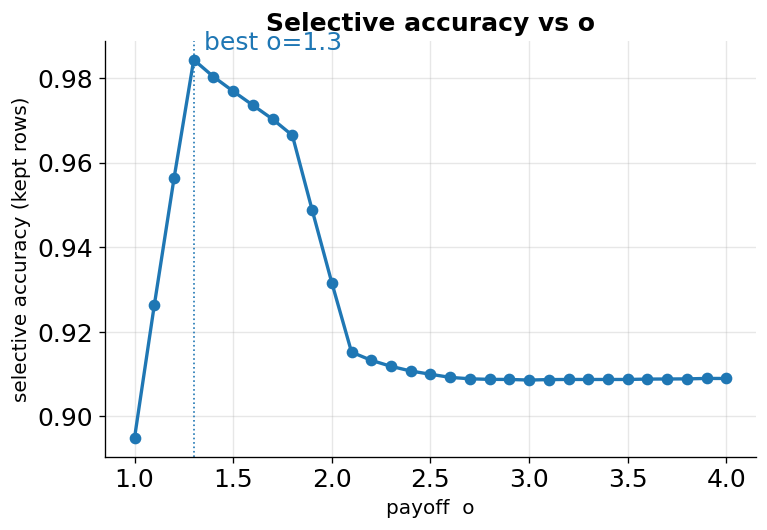

  o    sel
1.0 0.8943
1.1 0.8957
1.2 0.9890
1.3 0.9843
1.4 0.9799
1.5 0.9769
1.6 0.9739
1.7 0.9700
1.8 0.9670
1.9 0.9624
2.0 0.9172
2.1 0.9153
2.2 0.9132
2.3 0.9113
2.4 0.9110
2.5 0.9099
2.6 0.9090
2.7 0.9088
2.8 0.9089
2.9 0.9086
3.0 0.9087
3.1 0.9085
3.2 0.9089
3.3 0.9088
3.4 0.9085
3.5 0.9089
3.6 0.9088
3.7 0.9087
3.8 0.9090
3.9 0.9089
4.0 0.9091


In [6]:
# Selective accuracy vs the payoff o, on balanced_hard (the dataset that under-fits at low o).
# Each o's abstention model operates at its own reject decision but never below a coverage FLOOR;
# selective accuracy is the accuracy on the kept rows. As o rises the model abstains less and the
# curve settles onto the plain classifier -- so it rises to an interior peak, then comes back down.
# Needs results/cluster/*.pt + data/cluster/*.csv.
SEL_DS = "balanced_hard"
FLOOR = 0.60
SMOOTH_WIN = 3                # rolling-mean window for display smoothing (1 = raw, no smoothing)
pay_runs_all = [r for r in manifest["runs"] if "payoff" in (r.get("studies") or [])]
SELVO_SEEDS = sorted({r["seed"] for r in pay_runs_all})

pay_ds = sorted({r["dataset"] for r in pay_runs_all})
if SEL_DS not in pay_ds:      # fall back to the hardest-by-Bayes payoff dataset if not present
    def _bayes_acc(d):
        for r in pay_runs_all:
            if r["dataset"] == d and (root / r["metrics"]).exists():
                return json.loads((root / r["metrics"]).read_text()).get("bayes_optimal_accuracy", 1.0)
        return 1.0
    SEL_DS = min(pay_ds, key=_bayes_acc)
ds = SEL_DS
o_grid = sorted({r["o"] for r in pay_runs_all if r["loss"] == "abstention" and r["dataset"] == ds})

rows = []
csv = root / "data" / "cluster" / f"{ds}.csv"
if csv.exists():
    dfd = pd.read_csv(csv)
    for o in o_grid:
        for seed in SELVO_SEEDS:
            run = _find(ds, "abstention", o, seed)
            if not (run and (root / run["model"]).exists()):
                continue
            info = _infer(run, dfd)
            if not info["abstain"]:
                continue
            correct = (info["argmax"] == info["y"]).astype(float)
            acc = 1 - _risk_cov(-info["r"], correct)
            op_cov = max(float((info["r"] < 0.5).mean()), FLOOR)   # own coverage, never below the floor
            rows.append({"o": o, "sel": float(np.interp(op_cov, _covs, acc))})
selvo = pd.DataFrame(rows)
if len(selvo):
    sm = selvo.groupby("o")["sel"].mean().reset_index().sort_values("o").reset_index(drop=True)
    o_arr = sm["o"].to_numpy()
    sel_s = sm["sel"].rolling(SMOOTH_WIN, center=True, min_periods=1).mean().to_numpy()
    peak_i = int(np.nanargmax(sel_s)); peak_o = float(o_arr[peak_i])

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(o_arr, sel_s, marker="o", color="#1f77b4", lw=2)
    ax.axvline(peak_o, color="#1f77b4", ls=":", lw=1)
    ax.annotate(f"best o={peak_o:g}", (peak_o, sel_s[peak_i]),
                textcoords="offset points", xytext=(6, 6), color="#1f77b4")
    ax.set_xlabel("payoff  o"); ax.set_ylabel("selective accuracy (kept rows)")
    ax.set_title("Selective accuracy vs o")
    ax.grid(alpha=0.3)
    save_fig(fig, "fig_selective_vs_o"); plt.show()
    print(sm.round(4).to_string(index=False))
else:
    print(f"no abstention checkpoints for {ds}")

## Accuracy comparison (non-abstention vs abstention)

The non-abstention model at full coverage vs abstention's selective accuracy on the boards it answers (`r<0.5`), per dataset, coverage annotated. **Saved: `fig_cascade_vs_abstention_selective`.**

saved /fs1/projects/ProtoOKN/medical-device-rca/tex/img/fig_cascade_vs_abstention_selective.png (+ .pdf)


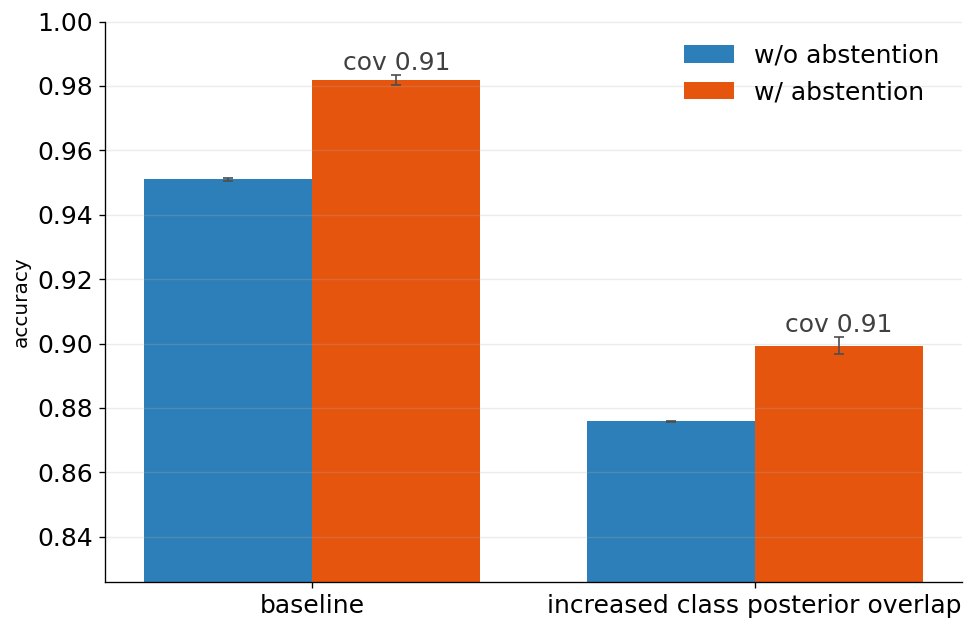

      baseline: non-abstention 0.9510   abstention 0.9817 @ cov 0.91   gain +0.0308
        harder: non-abstention 0.8759   abstention 0.8994 @ cov 0.91   gain +0.0235


In [7]:
# Accuracy comparison: non-abstention (full coverage) vs abstention at a per-dataset
# operating point. Uses the SAME o-swept data as the risk-coverage frontier -- each payoff o gives
# one (coverage@0.5, selective_acc@0.5) point (seed-averaged) -- and picks the o that best trades
# coverage for accuracy:  net = (selective_acc - non_abstention_acc) - PENALTY*(1 - coverage).
# So the abstention bar sits exactly on the risk-coverage curve. PENALTY tunes the mix (lower ->
# abstain more / lower coverage; higher -> keep coverage high). Error bars = +/-1 std over seeds.
PENALTY = 0.20
COV_MIN = 0.60
pay = study("payoff"); core = study("core")


def _ms(frame, ds, col):
    """(mean, std) over seeds for one dataset/column."""
    v = frame[frame.dataset == ds][col].dropna()
    return (float(v.mean()), float(v.std())) if len(v) else (np.nan, np.nan)


BAR_DATASETS = ["baseline", "harder"]                              # paper datasets
sm = seed_mean(pay, ["dataset", "o"], ["coverage@0.5", "selective_acc@0.5"])
rows = []
for ds in BAR_DATASETS:
    s = sm[sm.dataset == ds].dropna(subset=["coverage@0.5", "selective_acc@0.5"])
    if not len(s):
        continue
    na_m, na_s = _ms(core[core.loss == "cascade"], ds, "defect_acc")   # non-abstention model
    covv = s["coverage@0.5"].to_numpy(); accv = s["selective_acc@0.5"].to_numpy()
    net = (accv - na_m) - PENALTY * (1 - covv)
    net = np.where(covv >= COV_MIN, net, -np.inf)                  # avoid degenerate low coverage
    j = int(np.argmax(net))
    o_star = float(s["o"].to_numpy()[j])                           # the chosen payoff o
    sv = pay[(pay.dataset == ds) & (np.isclose(pay["o"], o_star))]["selective_acc@0.5"].dropna()
    ab_s = float(sv.std()) if len(sv) > 1 else 0.0
    rows.append((ds, na_m, na_s, float(accv[j]), ab_s, float(covv[j])))

rows.sort(key=lambda r: BAR_DATASETS.index(r[0]))                   # dataset order (baseline on the left)
labels = [r[0] for r in rows]; x = np.arange(len(labels)); w = 0.38
na_m = [r[1] for r in rows]; na_s = [r[2] for r in rows]
ab_m = [r[3] for r in rows]; ab_s = [r[4] for r in rows]; cov = [r[5] for r in rows]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ekw = dict(ecolor="0.3", capsize=3, elinewidth=1)
ax.bar(x - w/2, na_m, w, yerr=na_s, color=COLORS["cascade"],
       label="w/o abstention", error_kw=ekw)
ax.bar(x + w/2, ab_m, w, yerr=ab_s, color=COLORS["abstention"],
       label="w/ abstention", error_kw=ekw)
for xi, m, s, c in zip(x + w/2, ab_m, ab_s, cov):                  # coverage label on abstention bars
    ax.annotate(f"cov {c:.2f}", (xi, m + (0 if np.isnan(s) else s)),
                ha="center", va="bottom", fontsize=15, color="0.25")
allv = [v for v in na_m + ab_m if not np.isnan(v)]
ax.set_ylim(max(0.0, min(allv) - 0.05), 1.0)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("accuracy")
# ax.set_title("Non-abstention vs abstention accuracy")
# in x axis replace label harder with increased class posterior overlap
ax.set_xticklabels(["baseline", "increased class posterior overlap"])

ax.legend(loc="upper right"); ax.grid(axis="x", alpha=0)
fig.tight_layout(); save_fig(fig, "fig_cascade_vs_abstention_selective"); plt.show()
print("\n".join(f"{r[0]:>14}: non-abstention {r[1]:.4f}   abstention {r[3]:.4f} @ cov {r[5]:.2f}   gain {r[3]-r[1]:+.4f}" for r in rows))

## Comparing the datasets: selective-risk curves

Accepted error vs coverage on `baseline` + `harder`: abstention (min-max seed band) vs the no-rejection line. **Saved: `fig_selective_risk`.**

saved /fs1/projects/ProtoOKN/medical-device-rca/tex/img/fig_selective_risk.png (+ .pdf)


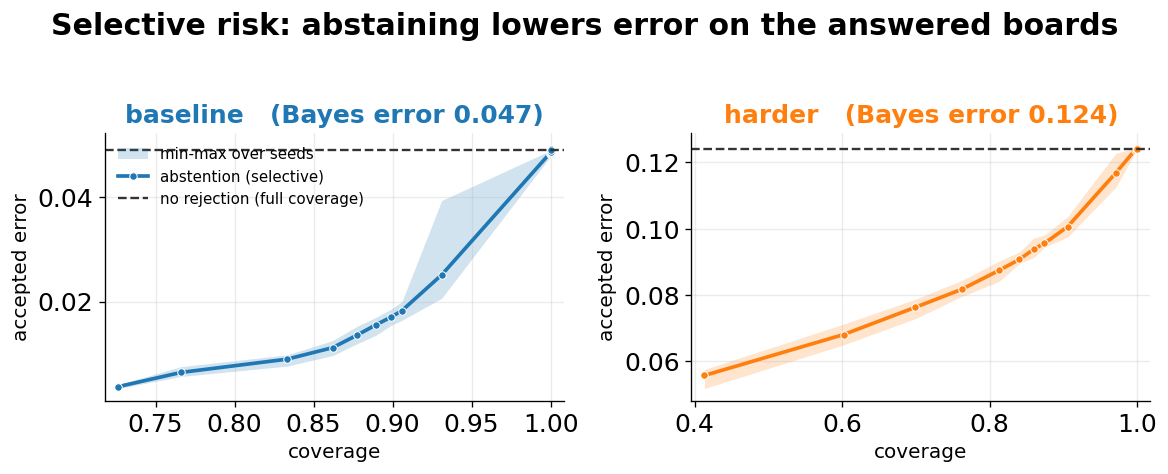

In [8]:
# PAPER FIGURE: selective-risk curves (accepted error vs coverage) for baseline + harder,
# built from the SAME o-swept data as the bar chart and the risk-coverage frontier -- each payoff
# o gives one (coverage@0.5, 1 - selective_acc@0.5) point (seed-averaged), so all three figures
# agree number-for-number. Each panel is colored by its dataset (matching the frontier). Line =
# seed mean; band = min..max over seeds; dashed line = non-abstention full-coverage error (the
# curve meets it at coverage 1 and falls below it as coverage drops).
RISK_DATASETS = ["baseline", "harder"]
pay = study("payoff"); core = study("core")
if len(pay):
    order = [d for d in RISK_DATASETS if d in set(pay["dataset"])]
    fig, axes = plt.subplots(1, len(order), figsize=(5.0 * len(order), 3.9), squeeze=False)
    sm = seed_mean(pay, ["dataset", "o"], ["coverage@0.5", "selective_acc@0.5"])
    for k, ds in enumerate(order):
        ax = axes[0][k]; c = dscolor(ds, k)
        s = (sm[sm.dataset == ds].dropna(subset=["coverage@0.5", "selective_acc@0.5"])
             .sort_values("coverage@0.5"))
        band = (pay[pay.dataset == ds].dropna(subset=["coverage@0.5", "selective_acc@0.5"])
                .groupby("o").agg(cov=("coverage@0.5", "mean"),
                                  amax=("selective_acc@0.5", "max"),
                                  amin=("selective_acc@0.5", "min")).sort_values("cov"))
        ax.fill_between(band["cov"], 1 - band["amax"], 1 - band["amin"],
                        color=c, alpha=0.20, lw=0, label="min-max over seeds")
        ax.plot(s["coverage@0.5"], 1 - s["selective_acc@0.5"], "-o", ms=4.5, lw=2.2, color=c,
                markeredgecolor="white", markeredgewidth=0.6, label="abstention (selective)")
        na = core[(core.dataset == ds) & (core.loss == "cascade")]["defect_acc"].mean()
        ax.axhline(1 - na, color=COLORS["bayes"], ls="--", lw=1.4, label="no rejection (full coverage)")
        bayes = 1 - core[core.dataset == ds]["bayes"].mean()
        ax.set_title(f"{ds}   (Bayes error {bayes:.3f})", color=c)
        ax.set_xlabel("coverage"); ax.set_ylabel("accepted error")
        ax.margins(x=0.03); ax.grid(alpha=0.25)
    axes[0][0].legend(loc="upper left", fontsize=9)
    fig.suptitle("Selective risk: abstaining lowers error on the answered boards",
                 fontweight="bold", y=1.02)
    fig.tight_layout(); save_fig(fig, "fig_selective_risk"); plt.show()
else:
    print("no payoff-study runs with metrics yet")